In [2]:
import Bio.PDB as pdb
from tp_pims.config import TP_PATH
import gudhi as gd
from gudhi import DelaunayCechComplex
from tp_pims.vizualize_filtration import draw_simplicial_complex, get_complexes_filtration
from tp_pims.vizualize_filtration import draw_ca_balls

# Introduction

This notebook aims to present to you a tool to perform TDA: [GUDHI](https://gudhi.inria.fr/python/latest/). This library offers you the possibility to create simplicial complexes from point cloud and compute persistent homology to analyze the topology of your point cloud. 

For now, the input is a protein from which we extract a point cloud. Each point is a position of an alpha carbon in the protein.

The first section illustrate the persistent homology on an alpha helix, the second part on a beta sheet and the third part analyze the whole protein.

To see the data we analyze, we will use PyMol to vizualize the 3D structure of the protein. You will see in red the alpha helix studied in the first section and in blue the beta sheet analyzed in second section. On the top of the screen you will also see the protein sequence colored.

In [3]:
path = str(TP_PATH / "script_pymol.py")
!pymol -q $path

^C


## PDB File


The first necessity is to load the coordinates of the alpha carbon of amino acid of the protein. To do so, we use an other extern library: [biopython](https://biopython.org/). This library allow us to read a PDB file and transform it as a Python object containing all informations in the [PDB](https://acces.ens-lyon.fr/acces/formation/formavie/formavie-2010/ressources-des-ateliers-2010/Les%20fichiers%20PDB_S.Dorey.pdf) file.

In [4]:
parser = pdb.PDBParser(PERMISSIVE=1)
protein = parser.get_structure(id=0, file=(TP_PATH / "data" / "AF-Q8U442-F1-model_v6.pdb").open("r"))


### Alpha helix

This function is an utility function to extract only alpha carbon coordinates from a list of residues. Here residues mean `biopython.Residue` instances which are amino acids. 

We use the utility function above and the knowledge about alpha helix position to extract only the corresponding alpha carbons.

In [5]:
alpha_helix_pos = [31, 43]
alpha_helix_first_turn_pos = [31, 36]
alpha_helix_aa = list(protein.get_residues())[alpha_helix_first_turn_pos[0]: alpha_helix_first_turn_pos[1]]
pos_ca = extract_ca_atom_pos(alpha_helix_aa)

NameError: name 'extract_ca_atom_pos' is not defined

 Detected OpenGL version 4.6. Shaders available.
 Detected GLSL version 4.60.
GL_ERROR : 0x0505 GenericBuffer::bufferData failed



At this point, `pos_ca` is a list containing all positions of alpha carbon of the alpha helix studied.

Each element of `pos_ca` represents an alpha carbon and is a list of 3 elements representing each coordinates of the alpha carbon in $\mathbb{R}^{3}$ 

We now use this point cloud to compute a filtration of it using the cech complex.

1. `cech_cs` is the implementation of the Cech complex
2. `cech_simplex_tree_sample` is an object representing the simplicial complex constructed from the cech filtration. It's a tree with al nodes being a simplicies and have filtration value associated to it.
3. `cech_barcode` is the implementation of the barcode obtained from the filtration when computing the persistence homology.

In [ ]:
cech_cs = DelaunayCechComplex(points = pos_ca)
cech_simplex_tree_sample = cech_cs.create_simplex_tree() 
cech_barcode = cech_simplex_tree_sample.persistence()

We now use two utilities to vizualize the result: one to vizualize the barcode and an other to show the persistence diagram.

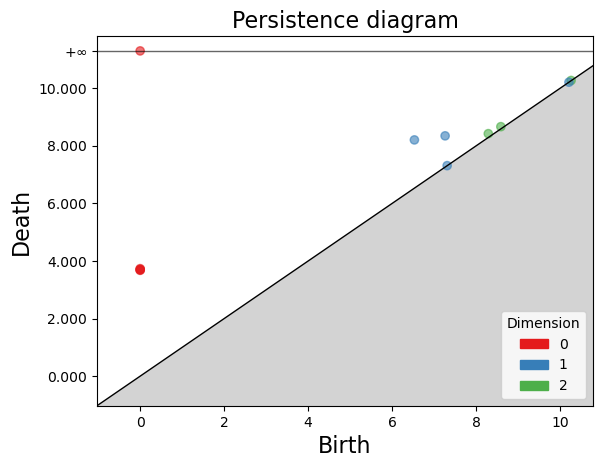

In [ ]:
gd.plot_persistence_diagram(cech_barcode);

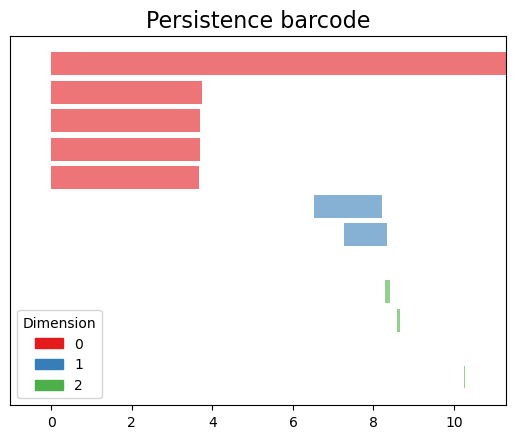

In [ ]:
gd.plot_persistence_barcode(cech_barcode);

In the next animations:

* Vertices (0-simplicies) are in orange
* Edges (1-simplicies) are in pink
* Triangles (2-simplicies) are in cyan
* Tetrahedrons (3-simplicies) are in dark blue

Can you see where the three cavities appear during the filtration?

In [ ]:
draw_simplicial_complex(pos_ca, cech_simplex_tree_sample)

21


### Beta sheet

Let's do exactly the same methodology on the beta sheet to see how is it filtered.

In [ ]:
beta_sheet_pos = [1, 11]

In [ ]:
beta_sheet_aa = list(protein.get_residues())[beta_sheet_pos[0]: beta_sheet_pos[1]]
pos_ca = extract_ca_atom_pos(beta_sheet_aa)

In [ ]:
cech_cs = DelaunayCechComplex(points = pos_ca)
cech_simplex_tree_sample = cech_cs.create_simplex_tree() 
cech_barcode = cech_simplex_tree_sample.persistence()

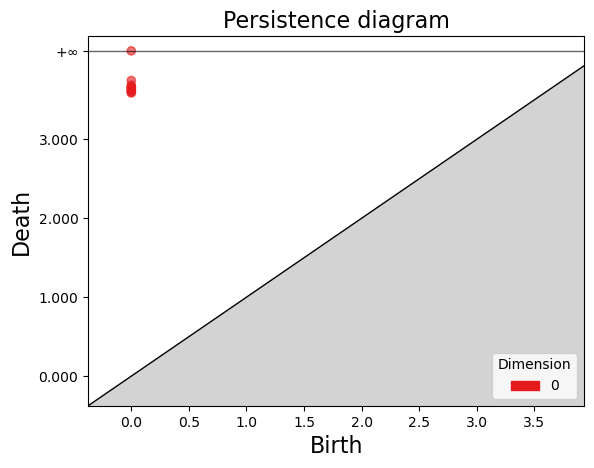

In [ ]:
gd.plot_persistence_diagram(cech_barcode);

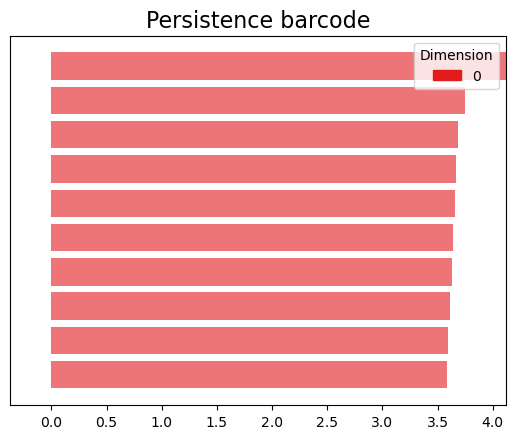

In [ ]:
gd.plot_persistence_barcode(cech_barcode);

### The whole protein

The last step is now to analyze the whole protein. I let you try to adapt the code above to use GUDHI to compute a filtration of the whole protein and to compute the persistent homolgy on this filtration.

In [ ]:
##draw_ca_balls(pos_ca, cech_simplex_tree_sample)